In [30]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

os.makedirs("models", exist_ok=True)
os.makedirs("figures", exist_ok=True)

features = pd.read_parquet("data/features.parquet")
split_index = pd.read_parquet("data/temporal_split_index.parquet")

df = features.copy()
df["issue_d"] = pd.to_datetime(split_index["issue_d"])

target_col = "loan_status"

X = df.drop(columns=[target_col, "issue_d"])
y = df[target_col].astype(int)

train_mask = df["issue_d"] < "2016-01-01"
val_mask = (df["issue_d"] >= "2016-01-01") & (df["issue_d"] < "2017-01-01")
test_mask = df["issue_d"] >= "2017-01-01"

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

X_val = X.loc[val_mask]
y_val = y.loc[val_mask]

X_test = X.loc[test_mask]
y_test = y.loc[test_mask]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (826604, 74)
Validation: (293095, 74)
Test: (225611, 74)


In [38]:
target_col = "loan_status"

X = df.drop(columns=[target_col, "issue_d"])

# remove any remaining datetime columns automatically
datetime_cols = X.select_dtypes(include=["datetime64[ns]"]).columns

print("Dropping datetime columns:", list(datetime_cols))

X = X.drop(columns=datetime_cols)
y = df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Target distribution:")
print(y.value_counts(normalize=True))

Dropping datetime columns: []
Train: (1076248, 74)
Test: (269062, 74)
Target distribution:
loan_status
0    0.800374
1    0.199626
Name: proportion, dtype: float64


In [40]:
sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)

model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=250,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=RANDOM_STATE
)

model.fit(X_train, y_train, sample_weight=sample_weight)

test_probs = model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

In [41]:
metrics = {
    "model": "HistGradientBoostingClassifier",
    "accuracy": accuracy_score(y_test, test_preds),
    "precision": precision_score(y_test, test_preds),
    "recall": recall_score(y_test, test_preds),
    "f1": f1_score(y_test, test_preds),
    "roc_auc": roc_auc_score(y_test, test_probs),
    "pr_auc": average_precision_score(y_test, test_probs)
}

metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(RESULTS_DIR / "gradient_boosting_metrics.csv", index=False)
metrics_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,HistGradientBoostingClassifier,0.656417,0.327576,0.685005,0.443206,0.730993,0.403856


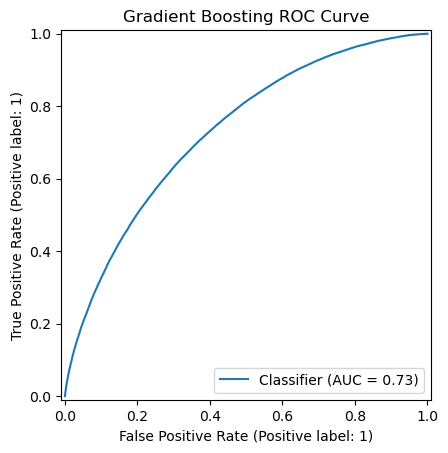

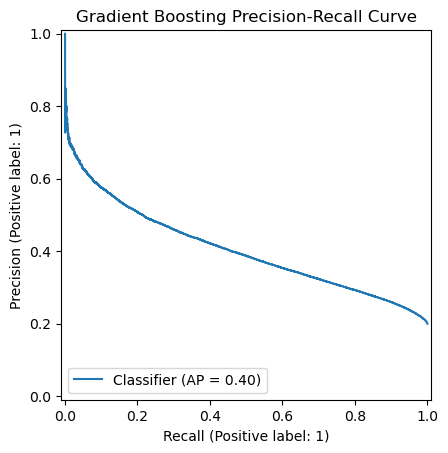

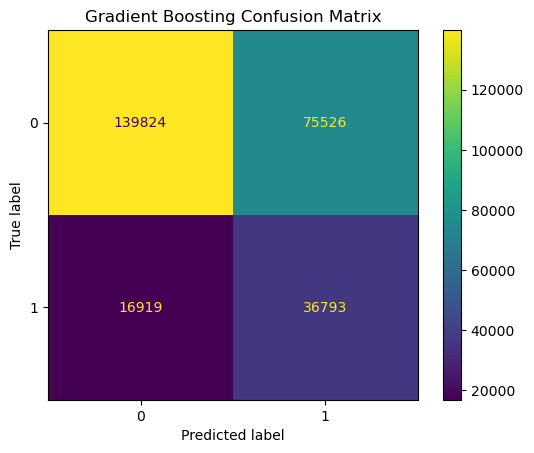

In [42]:
RocCurveDisplay.from_predictions(y_test, test_probs)
plt.title("Gradient Boosting ROC Curve")
plt.savefig(FIG_DIR / "gradient_boosting_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, test_probs)
plt.title("Gradient Boosting Precision-Recall Curve")
plt.savefig(FIG_DIR / "gradient_boosting_precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()

cm = confusion_matrix(y_test, test_preds)
ConfusionMatrixDisplay(cm).plot()
plt.title("Gradient Boosting Confusion Matrix")
plt.savefig(FIG_DIR / "gradient_boosting_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [43]:
sample_size = min(10000, len(X_test))
X_sample = X_test.sample(sample_size, random_state=RANDOM_STATE)
y_sample = y_test.loc[X_sample.index]

perm = permutation_importance(
    model,
    X_sample,
    y_sample,
    scoring="roc_auc",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

importance_df.head(15).to_csv(
    RESULTS_DIR / "gradient_boosting_feature_importance.csv",
    index=False
)

importance_df.head(15)

,feature,importance
2,sub_grade,0.070637
1,term,0.019702
52,installment_to_income,0.005966
6,dti,0.005934
18,acc_open_past_24mths,0.005010
59,home_ownership_RENT,0.004995
0,loan_amnt,0.003697
5,addr_state,0.003653
3,emp_length,0.003119
51,fico_avg,0.002402


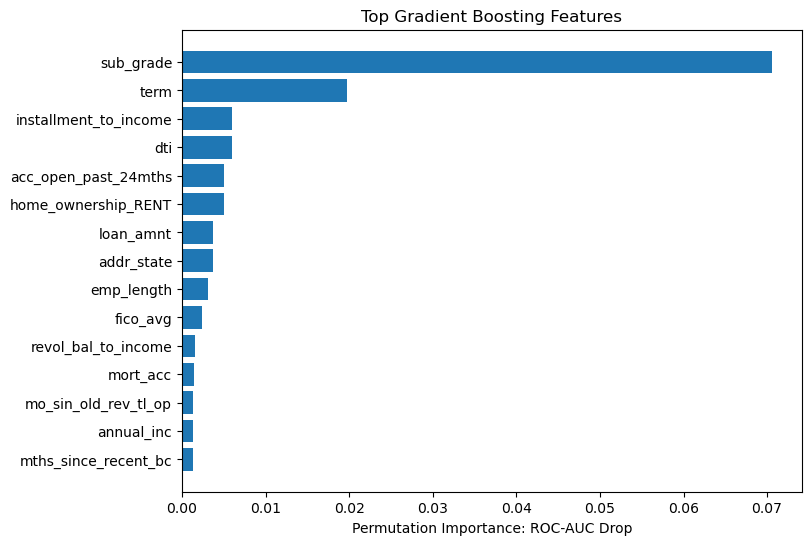

In [44]:
top = importance_df.head(15).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["importance"])
plt.xlabel("Permutation Importance: ROC-AUC Drop")
plt.title("Top Gradient Boosting Features")
plt.savefig(FIG_DIR / "gradient_boosting_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()